## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

## 1. Setup and data
Imports, device, and the *hotdog / not hotdog* dataset. 15% of the training images are held out as a validation
set for model selection; the test set is only used to report the final accuracies.

In [ ]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm
import copy
import time
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
num_workers = 4 if device.type == 'cuda' else 0
print(f"The code will run on {device} with {num_workers} data loader workers.")

The code will run on mps with 0 data loader workers.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y
    

Images are resized to $128\times128$ for the own CNN and $224\times224$ for ResNet-34. With `augment=True`
the training images get random resized crops, horizontal flips and colour jitter.

In [ ]:
# Data: transforms, train/validation split and loaders
CNN_SIZE = 128
RESNET_SIZE = 224
class_names = ['hotdog', 'not hotdog']


def make_transform(size, augment):
    steps = [transforms.Resize((size, size))]
    if augment:
        steps += [transforms.RandomResizedCrop(size, scale=(0.7, 1.0)),
                  transforms.RandomHorizontalFlip(),
                  transforms.ColorJitter(0.2, 0.2, 0.2)]
    return transforms.Compose(steps + [transforms.ToTensor()])


n_train = len(Hotdog_NotHotdog(train=True, transform=None))
perm = torch.randperm(n_train, generator=torch.Generator().manual_seed(0)).tolist()
n_val = int(0.15 * n_train)
val_idx, train_idx = perm[:n_val], perm[n_val:]


def make_loaders(size, augment, batch_size=64):
    train_set = Subset(Hotdog_NotHotdog(train=True, transform=make_transform(size, augment)), train_idx)
    val_set = Subset(Hotdog_NotHotdog(train=True, transform=make_transform(size, False)), val_idx)
    test_set = Hotdog_NotHotdog(train=False, transform=make_transform(size, False))
    return (DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True),
            DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers),
            DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers))


print(f"train: {len(train_idx)}, validation: {len(val_idx)}, "
      f"test: {len(Hotdog_NotHotdog(train=False, transform=None))} images")

Let's look at some images from our data 

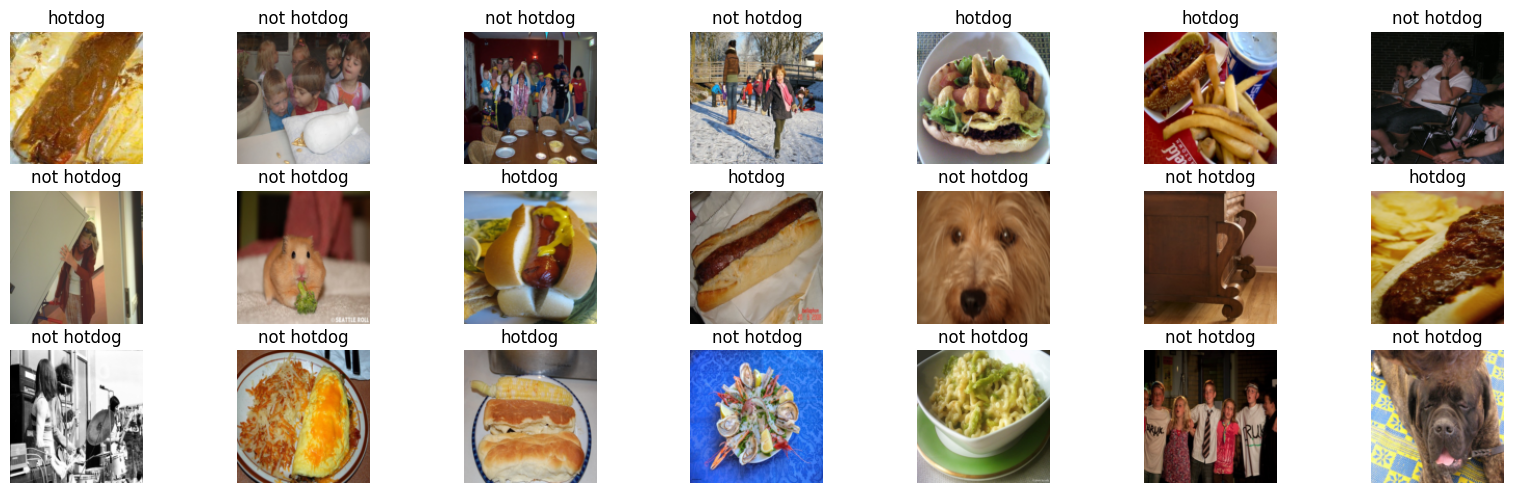

In [5]:
images, labels = next(iter(make_loaders(CNN_SIZE, augment=False)[0]))
plt.figure(figsize=(20, 10))
for i in range(21):
    plt.subplot(5, 7, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.show()

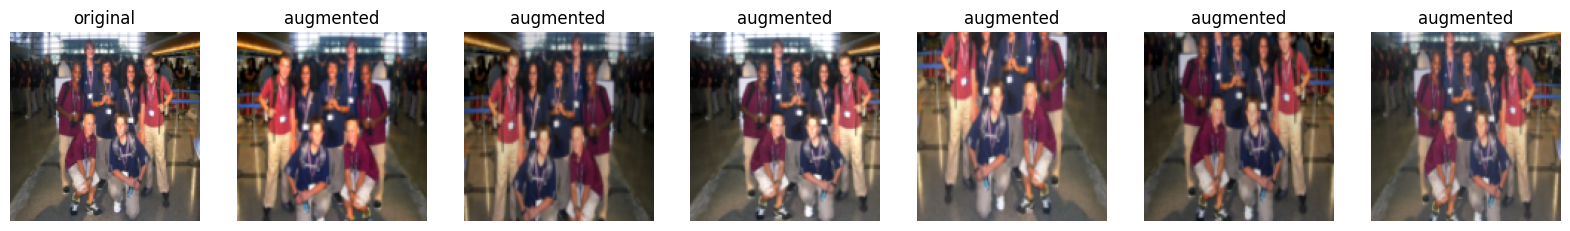

In [6]:
# Looking at augmented versions of one training image
plain_set = Hotdog_NotHotdog(train=True, transform=make_transform(CNN_SIZE, augment=False))
aug_set = Hotdog_NotHotdog(train=True, transform=make_transform(CNN_SIZE, augment=True))
plt.figure(figsize=(20, 4))
plt.subplot(1, 7, 1)
plt.imshow(plain_set[0][0].permute(1, 2, 0))
plt.title('original')
plt.axis('off')
for k in range(2, 8):
    plt.subplot(1, 7, k)
    plt.imshow(aug_set[0][0].permute(1, 2, 0))
    plt.title('augmented')
    plt.axis('off')
plt.show()

## 2. Models
### 2.1 Own CNN: the network from the lecture slides
One $5\times5$ convolution with 16 channels, $2\times2$ max pooling, and two fully connected hidden layers of
400 units, followed by the classification layer. `use_bn` adds batch normalization after the convolution and
after each hidden layer. Inputs are normalized with the ImageNet mean and standard deviation, like ResNet.

In [ ]:
# Own CNN: the network from the lecture slides, with optional batch normalization
class Normalize(nn.Module):
    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


def with_bn(layer, use_bn):
    'layer -> [BN] -> ReLU'
    bn = [nn.BatchNorm2d(layer.out_channels) if isinstance(layer, nn.Conv2d) else nn.BatchNorm1d(layer.out_features)]
    return [layer] + (bn if use_bn else []) + [nn.ReLU()]


class SlideNet(nn.Module):
    def __init__(self, size=128, use_bn=True, num_classes=2):
        super().__init__()
        feat = (size - 4) // 2  # spatial size after the 5x5 convolution and 2x2 max pooling
        self.normalize = Normalize()
        self.features = nn.Sequential(
            *with_bn(nn.Conv2d(3, 16, kernel_size=5, bias=not use_bn), use_bn),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            *with_bn(nn.Linear(feat * feat * 16, 400, bias=not use_bn), use_bn),
            *with_bn(nn.Linear(400, 400, bias=not use_bn), use_bn),
            nn.Linear(400, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(self.normalize(x)))


print(f"SlideNet at {CNN_SIZE}x{CNN_SIZE}: {sum(p.numel() for p in SlideNet(CNN_SIZE).parameters()) / 1e6:.1f} M parameters")

### 2.2 ResNet-34
`pretrained=True` starts from the ImageNet weights (transfer learning), `pretrained=False` trains from scratch.
The final layer is replaced with a two-class classifier.

In [10]:
# Models: ResNet-34 for transfer learning
def make_resnet(pretrained, num_classes=2):
    weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet34(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return nn.Sequential(Normalize(), model)

## 3. Training and experiments
Every run trains for 5 epochs with batch size 64 and keeps the weights of the epoch with the best validation
accuracy. `BASE` is the shared baseline (Adam, lr $10^{-3}$, augmentation on, batch norm on, pretrained ResNet);
every entry of `EXPERIMENTS` is a config dict overriding it. The experiments test, for both models:

* **Optimizer and learning rate** — Adam vs SGD (momentum 0.9) at lr $10^{-4}$, $10^{-3}$, $10^{-2}$ (full grid).
* **Data augmentation** — baseline vs no augmentation.
* **Batch normalization** (own CNN) — baseline vs no batch norm.
* **Transfer learning** (ResNet-34) — ImageNet-pretrained vs trained from scratch.

Already-trained configs are skipped, so new experiments can be appended and the training cell re-run.

In [11]:
# Training and evaluation
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        out = model(X)
        total_loss += criterion(out, y).item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


def train_model(model, optimizer, train_loader, val_loader, epochs):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = -1.0, None
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        val_loss, val_acc = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(correct / total)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc, best_state = val_acc, copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch + 1}/{epochs}: train loss {total_loss / total:.4f}, train acc {correct / total:.4f}, "
              f"val loss {val_loss:.4f}, val acc {val_acc:.4f}")
    model.load_state_dict(best_state)
    history['best_val_acc'] = best_val_acc
    return history

In [ ]:
# Experiment configs: shared baseline, optimizer x learning rate grid, and ablations
BASE = dict(epochs=5, batch_size=64, lr=1e-3, optimizer='adam', augment=True)
GRID = {'optimizer': ['adam', 'sgd'], 'lr': [1e-4, 1e-3, 1e-2]}  # full grid for both models
ABLATIONS = ['augment', 'use_bn', 'pretrained']  # each is ON in the baseline; one run per model with it OFF
MODELS = {
    'cnn': dict(label='Own CNN (SlideNet)', size=CNN_SIZE, defaults={'use_bn': True},
                make=lambda cfg: SlideNet(CNN_SIZE, use_bn=cfg['use_bn'])),
    'resnet34': dict(label='ResNet-34', size=RESNET_SIZE, defaults={'pretrained': True},
                     make=lambda cfg: make_resnet(cfg['pretrained'])),
}


def full_config(cfg):
    return {**BASE, **MODELS[cfg['model']]['defaults'], **cfg}


EXPERIMENTS = []
for model in MODELS:
    defaults = full_config({'model': model})
    for values in itertools.product(*GRID.values()):
        EXPERIMENTS.append({'model': model, **dict(zip(GRID, values))})
    EXPERIMENTS += [{'model': model, key: not defaults[key]} for key in ABLATIONS if key in defaults]
print(f"{len(EXPERIMENTS)} experiments:", *EXPERIMENTS, sep='\n')

In [ ]:
# Experiment runner
runs = {}


def run_name(cfg):
    defaults = {**BASE, **MODELS[cfg['model']]['defaults']}
    extras = ''.join(f"_{k}={v}" for k, v in cfg.items()
                     if k not in ('model', 'epochs', 'batch_size', 'lr') and defaults.get(k) != v)
    return f"{cfg['model']}_ep={cfg['epochs']}_bs={cfg['batch_size']}_lr={cfg['lr']}{extras}"


def run_experiment(cfg):
    cfg = full_config(cfg)
    name = run_name(cfg)
    if name in runs:  # already trained, e.g. when re-running after adding experiments
        return
    print(f"\n=== {name} ===")
    torch.manual_seed(0)
    spec = MODELS[cfg['model']]
    model = spec['make'](cfg).to(device)
    if cfg['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9)
    train_loader, val_loader, _ = make_loaders(spec['size'], cfg['augment'], cfg['batch_size'])
    start = time.time()
    history = train_model(model, optimizer, train_loader, val_loader, cfg['epochs'])
    runs[name] = {'model': model, 'history': history, 'config': cfg, 'size': spec['size'],
                  'minutes': (time.time() - start) / 60}

In [ ]:
for cfg in EXPERIMENTS:
    run_experiment(cfg)

## 4. Results
Learning curves show train (dashed) and validation (solid) loss and accuracy per epoch; the report figures
compare the best validation accuracy of each run.

In [ ]:
# Helpers: test accuracy of every run, run selection by config, learning-curve plot
test_loaders = {size: make_loaders(size, augment=False)[2] for size in {run['size'] for run in runs.values()}}
for run in runs.values():
    if 'test_acc' not in run:
        run['test_acc'] = evaluate(run['model'], test_loaders[run['size']])[1]

FACTOR_NAMES = {'optimizer': 'optimizer', 'lr': 'learning rate', 'augment': 'data augmentation',
                'use_bn': 'batch normalization', 'pretrained': 'ImageNet pretraining'}


def select(**fields):
    'Names of the runs whose config matches all given fields'
    return [name for name, run in runs.items() if all(run['config'].get(k) == v for k, v in fields.items())]


def sweep_runs(model, *keys):
    'Runs of `model` that differ from its baseline only in `keys` (baseline included), sorted by their values'
    base = full_config({'model': model})
    if any(key not in base for key in keys):
        return []
    strip = lambda cfg: {k: v for k, v in cfg.items() if k not in keys}
    names = [name for name, run in runs.items() if strip(run['config']) == strip(base)]
    return sorted(names, key=lambda name: tuple(runs[name]['config'][k] for k in keys))


def plot_curves(model, key):
    'Learning curves (dashed = train, solid = validation) of the runs varying `key` for `model`'
    names = sweep_runs(model, key)
    if len(names) < 2:
        return
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for name in names:
        h = runs[name]['history']
        epochs = range(1, len(h['val_loss']) + 1)
        label = f"{FACTOR_NAMES[key]} = {runs[name]['config'][key]}"
        line, = axes[0].plot(epochs, h['val_loss'], label=label)
        axes[0].plot(epochs, h['train_loss'], '--', color=line.get_color())
        axes[1].plot(epochs, h['val_acc'], color=line.get_color(), label=label)
        axes[1].plot(epochs, h['train_acc'], '--', color=line.get_color())
    axes[0].set_ylabel('loss')
    axes[1].set_ylabel('accuracy')
    style = [Line2D([], [], color='gray', linestyle='--'), Line2D([], [], color='gray')]
    for ax in axes:
        ax.set_xlabel('epoch')
        ax.set_xticks(range(1, max(len(runs[n]['history']['val_loss']) for n in names) + 1))
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles + style, labels + ['train', 'validation'], fontsize=8)
    fig.suptitle(f"{MODELS[model]['label']}: {FACTOR_NAMES[key]}")
    plt.show()

### 4.1 Optimizer and learning rate

In [ ]:
# Report figure: best validation accuracy against learning rate, one line per optimizer, one panel per model
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), sharey=True, squeeze=False)
for ax, (model, spec) in zip(axes[0], MODELS.items()):
    for opt in GRID['optimizer']:
        names = [n for n in sweep_runs(model, 'optimizer', 'lr') if runs[n]['config']['optimizer'] == opt]
        ax.plot([runs[n]['config']['lr'] for n in names], [runs[n]['history']['best_val_acc'] for n in names],
                'o-', label=opt)
    ax.set_xscale('log')
    ax.set_xlabel('learning rate')
    ax.set_title(spec['label'])
    ax.legend()
axes[0, 0].set_ylabel('best validation accuracy')
fig.suptitle('Optimizer and learning rate')
plt.show()

for model in MODELS:
    plot_curves(model, 'lr')         # learning rates with the baseline optimizer
    plot_curves(model, 'optimizer')  # optimizers at the baseline learning rate

### 4.2 Data augmentation

In [ ]:
for model in MODELS:
    plot_curves(model, 'augment')

### 4.3 Batch normalization (own CNN)

In [ ]:
plot_curves('cnn', 'use_bn')

### 4.4 Transfer learning (ResNet-34)

In [ ]:
plot_curves('resnet34', 'pretrained')


# First-layer filters: ResNet-34 trained from scratch vs pretrained on ImageNet
def show_filters(conv, title):
    w = conv.weight.detach().cpu()
    w = (w - w.min()) / (w.max() - w.min())
    fig, axes = plt.subplots(4, 16, figsize=(16, 4.5))
    for ax, f in zip(axes.flat, w):
        ax.imshow(f.permute(1, 2, 0))
        ax.axis('off')
    fig.suptitle(title)
    plt.show()


for pretrained, title in [(False, 'ResNet-34 trained from scratch'), (True, 'ResNet-34 pretrained on ImageNet')]:
    names = select(model='resnet34', pretrained=pretrained)
    if names:
        show_filters(runs[names[0]]['model'][1].conv1, f"{title} ({names[0]})")

### 4.5 Ablation summary

In [ ]:
# Report figure: best validation accuracy with each factor off vs on, per model
fig, axes = plt.subplots(1, len(ABLATIONS), figsize=(5 * len(ABLATIONS), 4), sharey=True, squeeze=False)
for ax, key in zip(axes[0], ABLATIONS):
    labels, off, on = [], [], []
    for model, spec in MODELS.items():
        names = sweep_runs(model, key)
        if len(names) == 2:  # sorted by value: False, True
            labels.append(spec['label'])
            off.append(runs[names[0]]['history']['best_val_acc'])
            on.append(runs[names[1]]['history']['best_val_acc'])
    x = np.arange(len(labels))
    ax.bar_label(ax.bar(x - 0.2, off, 0.4, label='off'), fmt='%.3f', fontsize=8)
    ax.bar_label(ax.bar(x + 0.2, on, 0.4, label='on'), fmt='%.3f', fontsize=8)
    ax.set_xticks(x, labels)
    ax.set_xlim(-0.7, len(MODELS) - 0.3)
    ax.set_ylim(0.4, 1.0)
    ax.set_title(FACTOR_NAMES[key])
axes[0, 0].set_ylabel('best validation accuracy')
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper right', ncol=2)
plt.show()

print(f"{'factor':22s} {'model':20s} {'off (val / test)':>18s} {'on (val / test)':>18s} {'val gain':>9s} {'test gain':>10s}")
for key in ABLATIONS:
    for model, spec in MODELS.items():
        names = sweep_runs(model, key)
        if len(names) != 2:
            continue
        off, on = [runs[n] for n in names]
        off_val, on_val = off['history']['best_val_acc'], on['history']['best_val_acc']
        print(f"{FACTOR_NAMES[key]:22s} {spec['label']:20s} {off_val:8.4f} / {off['test_acc']:6.4f} "
              f"{on_val:8.4f} / {on['test_acc']:6.4f} {on_val - off_val:+9.4f} {on['test_acc'] - off['test_acc']:+10.4f}")

### 4.6 All runs and model selection

In [ ]:
# All runs: validation and test accuracy, model selection on validation
print(f"{'run':44s} {'model':9s} {'opt':5s} {'lr':>6s} {'val acc':>8s} {'test acc':>9s} {'min':>6s}")
for name in sorted(runs, key=lambda n: (runs[n]['config']['model'], -runs[n]['history']['best_val_acc'])):
    run, cfg = runs[name], runs[name]['config']
    print(f"{name:44s} {cfg['model']:9s} {cfg['optimizer']:5s} {cfg['lr']:6.0e} "
          f"{run['history']['best_val_acc']:8.4f} {run['test_acc']:9.4f} {run['minutes']:6.1f}")

best_name = max(runs, key=lambda name: runs[name]['history']['best_val_acc'])
best_model = runs[best_name]['model']
test_loader = test_loaders[runs[best_name]['size']]
test_set = test_loader.dataset
print(f"\nSelected on validation: {best_name} (test acc {runs[best_name]['test_acc']:.4f})")

## 5. Analysis of the selected model
Confusion matrix and most confident mistakes on the test set, then saliency maps (vanilla gradient and SmoothGrad).

In [ ]:
# Test-set predictions and confusion matrix of the selected model
@torch.no_grad()
def predict(model, loader):
    model.eval()
    probs, ys = [], []
    for X, y in loader:
        probs.append(model(X.to(device)).softmax(1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)


probs, ys = predict(best_model, test_loader)
preds = probs.argmax(1)
confusion = torch.bincount(ys * 2 + preds, minlength=4).view(2, 2)
print(f"Test accuracy: {(preds == ys).float().mean().item():.4f}")
print(f"Confusion matrix (rows = true, columns = predicted, order {class_names}):")
print(confusion.numpy())

In [ ]:
# Most confident mistakes on the test set
wrong = (preds != ys).nonzero().flatten()
worst = wrong[probs[wrong, preds[wrong]].argsort(descending=True)][:12].tolist()
plt.figure(figsize=(20, 8))
for k, i in enumerate(worst):
    image, label = test_set[i]
    plt.subplot(2, 6, k + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"true: {class_names[label]}\npred: {class_names[preds[i]]} ({probs[i, preds[i]]:.2f})")
    plt.axis('off')
plt.show()

In [ ]:
# Saliency maps: vanilla gradient and SmoothGrad
def compute_saliency(model, image, target_class):
    model.eval()
    image = image.unsqueeze(0).to(device)
    image.requires_grad_()
    out = model(image)
    score = out[0, target_class]
    model.zero_grad()
    score.backward()
    saliency = image.grad.abs().squeeze().max(dim=0)[0]
    return saliency.cpu().numpy()


def smoothgrad_saliency(model, image, target_class, n_samples=50, sigma=0.15):
    model.eval()
    image = image.to(device)
    total_grad = torch.zeros_like(image)
    for _ in range(n_samples):
        noise = torch.randn_like(image) * sigma
        noisy_image = (image + noise).unsqueeze(0)
        noisy_image.requires_grad_()
        out = model(noisy_image)
        score = out[0, target_class]
        model.zero_grad()
        score.backward()
        total_grad += noisy_image.grad.squeeze()
    avg_grad = total_grad / n_samples
    saliency = avg_grad.abs().max(dim=0)[0]
    return saliency.cpu().numpy()


def show_saliency(model, dataset, idxs, sigma=0.15, n_samples=50):
    fig, axes = plt.subplots(3, len(idxs), figsize=(4 * len(idxs), 12), squeeze=False)
    for col, i in enumerate(idxs):
        image, label = dataset[i]
        model.eval()
        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device)).argmax(1).item()
        axes[0, col].imshow(image.permute(1, 2, 0))
        axes[0, col].set_title(f"true: {class_names[label]}, pred: {class_names[pred]}")
        axes[1, col].imshow(compute_saliency(model, image.clone(), pred), cmap='hot')
        axes[1, col].set_title('Vanilla saliency (predicted class)')
        axes[2, col].imshow(smoothgrad_saliency(model, image.clone(), pred, n_samples, sigma), cmap='hot')
        axes[2, col].set_title(f'SmoothGrad (sigma = {sigma})')
    for ax in axes.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Saliency for hotdog test images and for the most confident mistakes
hotdog_idxs = (ys == 0).nonzero().flatten()[:4].tolist()
show_saliency(best_model, test_set, hotdog_idxs)
if worst:
    show_saliency(best_model, test_set, worst[:4])

In [ ]:
# SmoothGrad for different noise levels sigma
sigmas = [0.05, 0.15, 0.3, 0.5]
image, label = test_set[hotdog_idxs[0]]
fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(4 * (len(sigmas) + 1), 4))
axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title('Image')
for ax, sigma in zip(axes[1:], sigmas):
    ax.imshow(smoothgrad_saliency(best_model, image.clone(), label, n_samples=50, sigma=sigma), cmap='hot')
    ax.set_title(f'sigma = {sigma}')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()